In [2]:
import sys
import os
import h5py
from pathlib import Path
from datetime import datetime

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from helpers.config import *
from model_training.model import *

import torch
from torch.utils.data import Dataset, random_split, DataLoader, Subset
import torchvision.models as models
import torch.nn as nn
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [36]:
model = CNN(width=6, bn=True, normalise=False)
device = torch.device("mps")
results_dir = TRAINING_RESULTS /'run_190726_113839'
weights_path = results_dir /'best_model_weights.pth'
#weights_path = results_dir / 'best_model_weights.pth'

model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()

CNN(
  (conv1): Conv2d(2, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(6, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=12288, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=2, bias=True)
)

## Confusion matrix

In [4]:
DEVICE = torch.device("mps")
def accuracy(model, loader, threshold=0.5):
    model.eval()
    
    soft_correct, hard_correct, soft_total, hard_total = 0, 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            images, labels = batch[0].to(DEVICE), batch[1].to(DEVICE)
            
            outputs = model(images)
            predicted = (torch.sigmoid(outputs) > threshold).float()
            soft_correct += (predicted == labels).sum().item()
            hard_correct += ((predicted == labels).all(dim=1)).sum().item()
            soft_total += labels.numel()
            hard_total += labels.size(0)
    
    soft_acc = soft_correct/soft_total
    hard_acc = hard_correct/hard_total
    return soft_acc, hard_acc

In [59]:
training_dataset_path2 = TRAINING_DATASETS / 'training_dataset.h5'
dataset = LISADataset(training_dataset_path2)

unique_indices = np.unique(dataset.sim_indices)
all_indices = np.array(dataset.sim_indices)

rng = np.random.default_rng(67)
rng.shuffle(unique_indices)

n_total = len(unique_indices)
n_train = int(0.7 * n_total)
n_val   = int(0.2 * n_total)

train_sources = unique_indices[:n_train]
val_sources   = unique_indices[n_train:n_train+n_val]
test_sources  = unique_indices[n_train+n_val:]

train_indices = np.where(np.isin(all_indices, train_sources))[0]
val_indices   = np.where(np.isin(all_indices, val_sources))[0]
test_indices  = np.where(np.isin(all_indices, test_sources))[0]

train_dataset = Subset(dataset, train_indices)
val_dataset   = Subset(dataset, val_indices)
test_dataset  = Subset(dataset, test_indices)

In [60]:
len(dataset)

17297

In [6]:
train_loader = DataLoader(train_dataset, batch_size=64)
train_soft_acc, train_hard_acc = accuracy(model, train_loader)

val_loader = DataLoader(val_dataset, batch_size=64)
val_soft_acc, val_hard_acc = accuracy(model, val_loader)

test_loader = DataLoader(test_dataset, batch_size=64)
test_soft_acc, test_hard_acc = accuracy(model, test_loader)

print(f"Training Soft Accuracy: {train_soft_acc:.4f}, Training Hard Accuracy: {train_hard_acc:.4f}")
print(f"Validation Soft Accuracy: {val_soft_acc:.4f}, Validation Hard Accuracy: {val_hard_acc:.4f}")
print(f"Test Soft Accuracy: {test_soft_acc:.4f}, Test Hard Accuracy: {test_hard_acc:.4f}")

Training Soft Accuracy: 0.9991, Training Hard Accuracy: 0.9983
Validation Soft Accuracy: 0.9956, Validation Hard Accuracy: 0.9912
Test Soft Accuracy: 0.9953, Test Hard Accuracy: 0.9906


In [38]:
model.eval()

loader = DataLoader(test_dataset, batch_size=64)

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in loader:
        images = batch[0].to(device)
        labels = batch[1]

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.append(preds.cpu())
        all_probs.append(probs.cpu())
        all_labels.append(labels)

preds = torch.cat(all_preds)
labels = torch.cat(all_labels)
probs = torch.cat(all_probs)

In [8]:
from sklearn.metrics import roc_curve, auc

probs = np.array(probs)
labels = np.array(labels)

fpr_gw, tpr_gw, _ = roc_curve(
    labels[:, 0],
    probs[:, 0]
)
fpr_glitch, tpr_glitch, _ = roc_curve(
    labels[:, 1],
    probs[:, 1]
)
auc_gw = auc(fpr_gw, tpr_gw)
auc_glitch = auc(fpr_glitch, tpr_glitch)

print("GW AUC =", auc_gw)
print("Glitch AUC =", auc_glitch)

#np.savez(results_dir / 'roc_curves.npz', fpr_gw=fpr_gw,tpr_gw=tpr_gw, auc_gw=auc_gw,
 #       fpr_glitch=fpr_glitch, tpr_glitch=tpr_glitch, auc_glitch=auc_glitch)

GW AUC = 0.9999987810006766
Glitch AUC = 0.9982747712672766


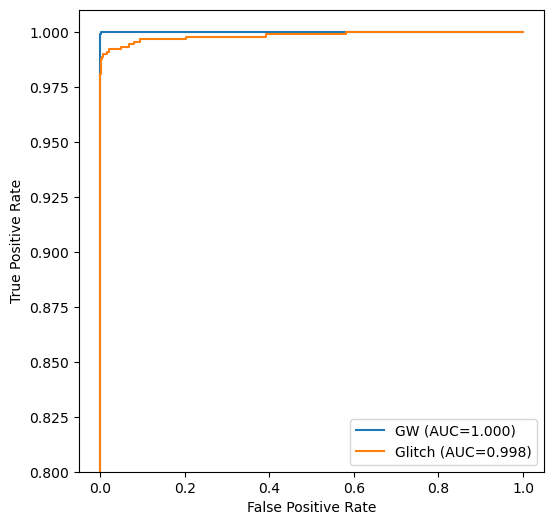

In [12]:
plt.figure(figsize=(6,6))

plt.plot(
    fpr_gw,
    tpr_gw,
    label=f'GW (AUC={auc_gw:.3f})'
)

plt.plot(
    fpr_glitch,
    tpr_glitch,
    label=f'Glitch (AUC={auc_glitch:.3f})'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.ylim(0.8, 1.01)
plt.legend()

plt.show()

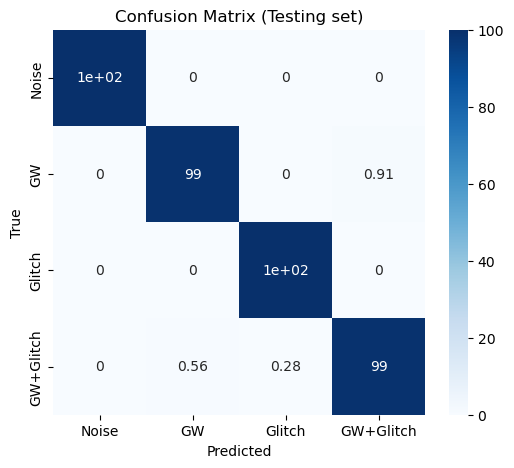

In [39]:
def label_to_class(y):
    return y[:,0]*1 + y[:,1]*2

true_class = label_to_class(labels)
pred_class = label_to_class(preds)
cm = confusion_matrix(true_class, pred_class, normalize='true')*100

labels_names = ["Noise", "GW", "Glitch", "GW+Glitch"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=labels_names,
            yticklabels=labels_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Testing set)")

plt.show()

In [40]:
wrong = np.where((true_class == 3)&(pred_class == 1))[0]
wrong

array([977, 978])

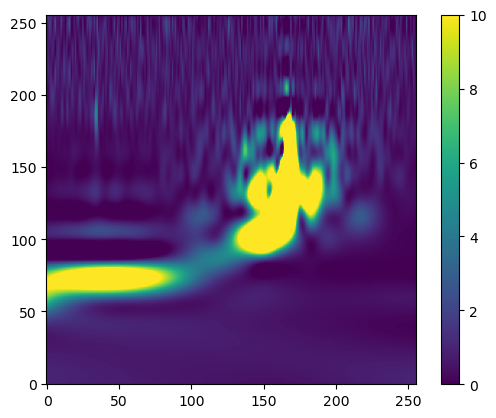

True label: tensor([1., 1.])
Sim index: 414
Time index: 2


In [44]:
image, label, sim_index, time_index = test_dataset[978]
plt.imshow(image[0], origin='lower')
plt.colorbar()
plt.clim(0, 10)
plt.show()
print('True label:', label)
print('Sim index:', sim_index)
print('Time index:', time_index)

In [39]:
wrong = np.where((true_class == 3)&(pred_class == 1))[0]
sim_indices = [test_dataset[i][2] for i in wrong]
all_indices = [test_dataset[i][2] for i in range(len(test_dataset))]

In [41]:
sim_indices = np.unique(sim_indices)
with h5py.File(mixed_dataset_path, 'r') as f:
    amps = f['amp'][:]
    betas = f['beta'][:]
    inj_points = f['inj_point'][:]

wrong_amps = amps[sim_indices]
wrong_betas = betas[sim_indices]

all_amps = amps[all_indices]
all_betas = betas[all_indices]

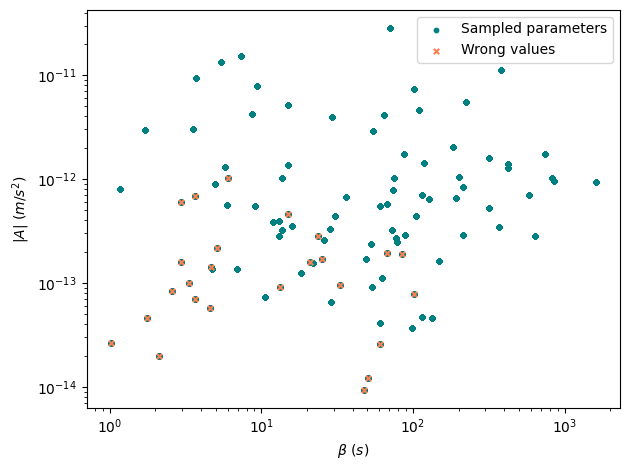

In [42]:
plt.figure(tight_layout=True)
plt.scatter(all_betas, all_amps, color='teal', s=10, label='Sampled parameters')
plt.scatter(wrong_betas, np.abs(wrong_amps), color='coral', s=15, marker='x', label='Wrong values')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('$|A|\ (m/s^2)$')
plt.xlabel('$\\beta\ (s)$')
plt.legend()
plt.show()